<center><h2> Generating LSST multi-band postage stamps

In this notebook, we generate samples of various sizes for the time-delay measurement project. The end result of this notebook is a csv generated with the following properties (at minimum):
* microlensing parameters
    * convergence: $\kappa$
    * stellar convergence: $\kappa_*$
    * shear: $\gamma$
* black hole accretion and transfer function parameters required by AMOEBA
    * black hole mass
    * eddington rate
    * black hole accretion disk inclination angle
* variability parameters required for a damped random walk generated using a bending power-law with fixed lower slope of 0 and higher slope of 2
    * $SF_\infty$ = $\sqrt2\sigma$ where $\sigma$ is the standard deviation of light curve variation from the mean
    * $\tau_{\rm DRW}$ where the breakpoint frequency = $1/\sqrt(2\pi\tau_{\rm DRW})$
* lensed magnitudes of 2/3/4 images
* arrival times of 2/3/4 images

All of this information is stored as a metadata in the final hdf5 file with time series postage stamps.

### Import required pacakges

In [1]:
### Cosmology and astropy packages
from astropy.cosmology import FlatLambdaCDM
from astropy.units import Quantity
import astropy.coordinates as coord
import astropy.units as u

### Arrays, tables, plots
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### SLSim functions
import slsim.Sources as sources
import slsim.Deflectors as deflectors
import slsim.Pipelines as pipelines
from slsim.Sources.SourceCatalogues.QuasarCatalog.quasar_pop import QuasarRate
from slsim.Lenses.lens_pop import LensPop
from slsim.ImageSimulation.image_simulation import (
    point_source_coordinate_properties,
    lens_image_series,
)


from slsim.Util.param_util import ellipticity2phi_q

# from slsim.Util.distribution_plot_utils import make_contour
from slsim.LsstSciencePipeline.rubin_sim_pipeline import get_rubin_cadence
from lenstronomy.Util.data_util import bkg_noise

### Readin, readout, paths
from contextlib import redirect_stdout
import io
from tqdm import tqdm
from tqdm import tqdm

### recompile packages after each edit
%load_ext autoreload
%autoreload 2

/global/common/software/m1727/vpadma/slsim_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Set up SLSim to generate populations

In [2]:
# define a cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# define a sky area
galaxy_sky_area = Quantity(
    value=10, unit="deg2"
)  # this is the sky area over which galaxies are sampled
quasar_sky_area = Quantity(value=10, unit="deg2")

# this is the sky area over which lensed quasars are sampled
full_sky_area = Quantity(value=5000, unit="deg2")

# define limits in the intrinsic deflector and source population (in addition
# to the skypy config
# file)
kwargs_deflector_cut = {"band": "i", "band_max": 28, "z_min": 0.01, "z_max": 2.5}
kwargs_source_cut = {"band": "i", "band_max": 26, "z_min": 0.001, "z_max": 6.0}

In [3]:
# generate galaxy population using skypy pipeline.
galaxy_simulation_pipeline = pipelines.SkyPyPipeline(
    skypy_config=None,
    sky_area=galaxy_sky_area,
    filters=["u", "g", "r", "i", "z", "y"],
    cosmo=cosmo,
    z_min=0,
)

### Generate lens galaxy population

In [4]:
lens_galaxies_ell = deflectors.EllipticalLensGalaxies(
    galaxy_list=galaxy_simulation_pipeline.red_galaxies,
    kwargs_cut=kwargs_deflector_cut,
    kwargs_mass2light={},
    cosmo=cosmo,
    sky_area=galaxy_sky_area,
    gamma_pl=dict(mean=2.0, std_dev=0.16),
)

/global/u1/v/vpadma/postage_stamp_generation/src/slsim/slsim/Deflectors/DeflectorPopulation/elliptical_lens_galaxies.py:48: UserWarning: Angular size is converted to arcsec because provided input_catalog_type is skypy. If this is not correct, please refer to the documentation of the class you are using
  galaxy_list = param_util.catalog_with_angular_size_in_arcsec(


In [5]:
# Initiate QuasarRate class to generate quasar sample.
quasar_class = QuasarRate(
    cosmo=cosmo,
    sky_area=quasar_sky_area,
    noise=True,
    redshifts=np.linspace(0.001, 6.00, 100),  # these redshifts are provided
    # to match general slsim redshift range in skypy pipeline.
)
# quasar sample with host galaxy
quasar_source_plus_galaxy = quasar_class.quasar_sample(
    m_min=15, m_max=28, host_galaxy=True
)

Matching quasars with host galaxies: 100%|██████████| 45466/45466 [00:25<00:00, 1794.98it/s]


In [6]:
# Prepare dictionary of agn variability kwargs
length_of_light_curve = 3850
MACLEOD2010_MEANS = np.array(
    [8.53308079, -23.48721021, -0.51665998, 2.28708691, 2.11640976]
)
MACLEOD2010_COV = np.array(
    [
        [0.27862905, -0.29501766, 0.00675703, 0.04606804, -0.00665875],
        [-0.29501766, 2.06855169, 0.19690851, 0.0244139, -0.29913764],
        [0.00675703, 0.19690851, 0.02785685, 0.01083628, -0.02216221],
        [0.04606804, 0.0244139, 0.01083628, 0.05636087, -0.02716507],
        [-0.00665875, -0.29913764, -0.02216221, -0.02716507, 0.3077278],
    ]
)
#############################################################################


# Prepare dictionary of agn variability kwargs
# Note: the means array and covariance matrix should be defined in following order and units:
# log(BH_mass/Msun), M_i, log(SFi_inf/mag), log(tau/days), zsrc
# variable_agn_kwarg_dict = {
#     "multivariate_gaussian_means": MACLEOD2010_MEANS,
#     "multivariate_gaussian_covs": MACLEOD2010_COV,
#     "known_band": "lsst2016-i",
# }
variable_agn_kwarg_dict = {
    "length_of_light_curve": length_of_light_curve,
    "time_resolution": 1,
    # "log_breakpoint_frequency": 1 / 20,
    # "low_frequency_slope": 1,
    # "high_frequency_slope": 3,
    # "standard_deviation": 0.9,
}
# variable_agn_kwarg_dict = {}
kwargs_quasar = {
    "variability_model": "light_curve",
    "kwargs_variability": {"agn_lightcurve", "u", "g", "r", "i", "z", "y"},
    "agn_driving_variability_model": "bending_power_law_from_distribution",
    "agn_driving_kwargs_variability": variable_agn_kwarg_dict,
    "lightcurve_time": np.linspace(0, length_of_light_curve, length_of_light_curve),
    "corona_height": 10,
    "r_resolution": 500,
}
# Initiate source population class.
source_quasar_plus_galaxies = sources.PointPlusExtendedSources(
    point_plus_extended_sources_list=quasar_source_plus_galaxy,
    cosmo=cosmo,
    sky_area=quasar_sky_area,
    kwargs_cut=kwargs_source_cut,
    list_type="astropy_table",
    catalog_type="skypy",
    point_source_type="quasar",
    extended_source_type="single_sersic",
    point_source_kwargs=kwargs_quasar,
)

In [7]:
# Initiate LensPop class to generate lensed quasar pop.
quasar_lens_pop_ell = LensPop(
    deflector_population=lens_galaxies_ell,
    source_population=source_quasar_plus_galaxies,
    cosmo=cosmo,
    sky_area=full_sky_area,
)
image_sep = 0.5
mag_lim = 24
kwargs_lens_cuts = {
    "min_image_separation": image_sep,
    "max_image_separation": 10,
    "second_brightest_image_cut": {"i": mag_lim},
}
# drawing population
# the key difference in lens population drawing time is whether you ask for magnitude cuts or not I think?
# quasar_lens_population = []
# for i in tqdm(range(1)):
qlp5000 = quasar_lens_pop_ell.draw_population(
    speed_factor=1000, kwargs_lens_cuts=kwargs_lens_cuts
)
    # quasar_lens_population.extend(qlp5000)

In [22]:
import os
os.cpu_count()


256

### What are the second brightest i-band mags:

In [8]:
mags = []
uls = []
for lens in qlp5000:
    image_magnitude_list = lens.point_source_magnitude(
                        band='i', lensed=True
                    )
    ul = lens.point_source_magnitude(
                        band='i', lensed=False
                    )
    mag2 = np.sort(image_magnitude_list[0])[1]
    uls.append(ul[0])
    mags.append(mag2)

(array([  1.,   1.,  11.,  41.,  81., 131., 167., 168.,  97.,  29.]),
 array([16.46403459, 17.41604596, 18.36805734, 19.32006871, 20.27208008,
        21.22409145, 22.17610283, 23.1281142 , 24.08012557, 25.03213694,
        25.98414831]),
 <BarContainer object of 10 artists>)

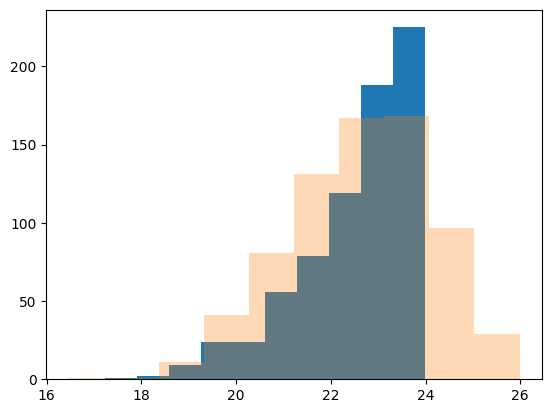

In [9]:
plt.hist(mags)
plt.hist(uls, alpha=0.3)

### Make the dataframe for the population

In [15]:
import warnings
warnings.filterwarnings('ignore')

In [16]:
quasar_lens_population = qlp5000

In [23]:
f = io.StringIO()
full_pop_df = pd.DataFrame()
with redirect_stdout(f):
    for i, lens_obj in tqdm(enumerate(qlp5000)):
        full_pop_df = lens_obj.lens_to_dataframe(index=i, df=full_pop_df)
        image2mag = full_pop_df.loc[i, "point_source_light_i_magnitude_1"]
        try:
            image3mag = full_pop_df.loc[i, "point_source_light_i_magnitude_2"]
        except KeyError:
            image3mag = 0
        second_or_third_mag = (
            image3mag if not (np.isnan(image3mag) or image3mag == 0) else image2mag)
        
        full_pop_df.loc[i, "i2"] = image2mag
        full_pop_df.loc[i, "i3"] = second_or_third_mag
        (
            full_pop_df.loc[i, "deflector_mass_phi"],
            full_pop_df.loc[i, "deflector_mass_q"],
        ) = ellipticity2phi_q(
            full_pop_df.loc[i, "deflector_mass_e1"],
            full_pop_df.loc[i, "deflector_mass_e2"],
        )
        (
            full_pop_df.loc[i, "deflector_light_phi"],
            full_pop_df.loc[i, "deflector_light_q"],
        ) = ellipticity2phi_q(
            full_pop_df.loc[i, "deflector_light_i_e1"],
            full_pop_df.loc[i, "deflector_light_i_e2"],
        )
        full_pop_df.loc[i, "deflector_stellar_mass"] = lens_obj.deflector_stellar_mass()
        full_pop_df.loc[i, "lens_obj"] = lens_obj
        for band in list("ugrizy"):
            abs_mag = quasar_class.convert_magnitude(
                full_pop_df.loc[i, f"ps_{band}_mag_true"],
                full_pop_df.loc[i, "point_source_redshift"],
                conversion="apparent_to_absolute",
            )
            full_pop_df.loc[i, f"M_{band}"] = abs_mag
            if np.isnan(abs_mag):
                if band == "y":
                    full_pop_df.drop(index=i, inplace=True)

0it [00:00, ?it/s]/global/u1/v/vpadma/postage_stamp_generation/src/slsim/slsim/Sources/SourceTypes/quasar.py:308: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  band_to_mag_with_offset["z"] = band_to_mag_with_offset["i"] - selected_sample[5]
/global/u1/v/vpadma/postage_stamp_generation/src/slsim/slsim/Sources/SourceTypes/quasar.py:309: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  band_to_mag_with_offset["r"] = band_to_mag_with_offset["i"] + selected_sample[4]
/global/u1/v/vpadma/postage_stamp_generation/src/slsim/slsim/Sources/SourceTypes/quasar.py:310: FutureWarning: Series.__getitem__ treating keys as positions is 

(array([ 0.,  0.,  0.,  1.,  0.,  5.,  3.,  8., 12., 12., 11., 22., 30.,
        30., 34., 32., 49., 42., 53., 50., 65., 39., 47., 53., 46., 27.,
        31., 23., 13., 10.,  4.,  4.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]),
 array([17.        , 17.30612245, 17.6122449 , 17.91836735, 18.2244898 ,
        18.53061224, 18.83673469, 19.14285714, 19.44897959, 19.75510204,
        20.06122449, 20.36734694, 20.67346939, 20.97959184, 21.28571429,
        21.59183673, 21.89795918, 22.20408163, 22.51020408, 22.81632653,
        23.12244898, 23.42857143, 23.73469388, 24.04081633, 24.34693878,
        24.65306122, 24.95918367, 25.26530612, 25.57142857, 25.87755102,
        26.18367347, 26.48979592, 26.79591837, 27.10204082, 27.40816327,
        27.71428571, 28.02040816, 28.32653061, 28.63265306, 28.93877551,
        29.24489796, 29.55102041, 29.85714286, 30.16326531, 30.46938776,
        30.7755102 , 31.08163265, 31.3877551 , 31.69387755, 32. 

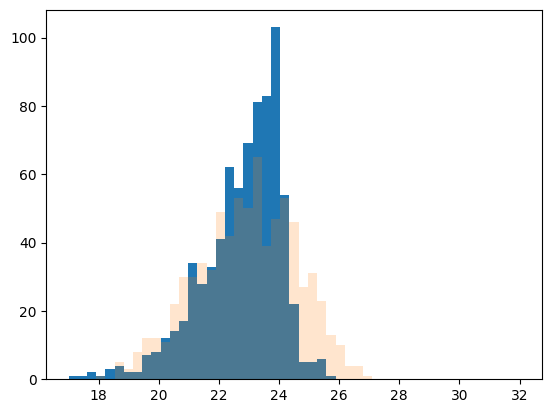

In [18]:
_, bins, _ = plt.hist(full_pop_df[f'point_source_light_i_magnitude_{1}'], bins=np.linspace(17, 32,50))
plt.hist(full_pop_df[f'ps_i_mag_true'], alpha=0.2, bins=bins)

### Generate images

In [10]:
def get_random_ra_dec(N=1):
    ra_points = coord.Angle(np.random.uniform(low=0, high=360, size=N) * u.degree)
    ra_points = ra_points.wrap_at(180 * u.degree)
    # dec goes from -72 to +12
    lower = -70
    upper = 10
    p = (
        np.sin(np.random.uniform(low=lower, high=upper, size=N) * u.deg)
        - np.sin(lower * u.deg)
    ) / (np.sin(upper * u.deg) - np.sin(lower * u.deg))
    dec_points = coord.Angle(
        ((((np.arcsin(2 * p - 1).to(u.deg) + 90 * u.deg) / (180 * u.deg)) * 84) + lower)
        * u.deg
    )
    return ra_points, dec_points

def compute_magnitude_zeropoint(mag_zp_1s, exposure_time=30, gain=1):
        return mag_zp_1s + 2.5 * np.log10(exposure_time / gain)

In [11]:
lsst_colors = {
    "u": "#0c71ff",
    "g": "#49be61",
    "r": "#c61c00",
    "i": "#ffc200",
    "z": "#f341a2",
    "y": "#5d0000",
}

In [12]:
# new_ra, new_dec = get_random_ra_dec(N=1)
# rubin_df = get_rubin_cadence(new_ra, new_dec)
# observation_dates = rubin_df["observationStartMJD"]
# time = np.arange(0, length_of_light_curve, 1)


In [13]:
# lens_class=quasar_lens_population[3]
# image_number = lens_class.image_number
# lens_class.ra_image = np.array([new_ra.deg])
# lens_class.dec_image = np.array([new_dec.deg])

In [14]:
# # Select 5 random lenses
# # random_lenses = np.random.choice(full_pop_df['lens_obj'], size=5, replace=False)

# # Loop through each lens, change RA and Dec, and plot the light curves
# # for lens_class in random_lenses:
# # Get random RA and Dec
# # new_ra, new_dec = get_random_ra_dec(N=1)
# # lens_class.ra_image = np.array([new_ra.deg])
# # lens_class.dec_image = np.array([new_dec.deg])

# # Get Rubin cadence for the new RA and Dec
# # rubin_df = get_rubin_cadence(new_ra, new_dec)

# # observation_dates = rubin_df["observationStartMJD"]
# # time = np.arange(0, length_of_light_curve, 1)
# # image_number = lens_class.image_number
# if isinstance(image_number, list):
#     image_number = image_number[
#         0
#     ]  # taking the number of images from the first plane source

# fig, ax = plt.subplots(1, image_number, figsize=(30, 7))
# ax = ax.flatten()

# for band in list("ugrizy"):
#     time_sampled = np.array(
#         observation_dates[band]
#     )  # we're picking the dates that we expect to observe with Rubin
#     # loop through the bands and plot the light curves
#     for i in range(image_number):
#         ax[i].plot(
#             time,
#             lens_class.point_source_magnitude(
#                 band=band, lensed=True, time=time, microlensing=False
#             )[0][i],
#             label=f"{band}-band, image-{i+1}",
#             color=lsst_colors[band],
#             alpha=0.2,
#         )
#         ax[i].scatter(
#             time_sampled,
#             lens_class.point_source_magnitude(
#                 band=band, lensed=True, time=time_sampled, microlensing=True
#             )[0][i],
#             marker="*",
#             s=100,
#             color=lsst_colors[band],
#         )

# ax[0].set_ylabel("Magnitude", fontsize=20)
# fig.supxlabel("Time [Days]", fontsize=20)
# for a in ax:
#     a.invert_yaxis()
#     a.legend()
# fig.suptitle(
#     f"Light curves for {lens_class.image_number} images of a multiply-imaged quasar",
#     fontsize=30,
# )
# fig.tight_layout()
# plt.show()

In [15]:
# transform_matrix = np.array([[delta_pix, 0], [0, delta_pix]])

# # let's set up psf kernel for each exposure. Here we have taken the same psf that we
# # extracted above. However, each exposure can have different psf kernel and user should
# # provide corresponding psf kernel to each exposure.
# psf_kernel_list = [None]
# transform_matrix_list = [transform_matrix]
# image_lens_series_all_bands = []
# for band in tqdm(list("u")):
#     time_sampled = observation_dates[band]
#     repeats = len(time_sampled)
#     mag_list = [mag_zero_points_30_seconds[band]]
#     expo_list = [exp_time]
#     mag_zero_points_all = mag_list * repeats
#     psf_kernels_all = psf_kernel_list * repeats
#     transform_matrix_all = transform_matrix_list * repeats
#     exposure_time_all = expo_list * repeats
#     # image_lens_series = lens_image_series(
#     #     lens_class=lens_class,
#     #     band=band,
#     #     mag_zero_point=mag_zero_points_all,
#     #     num_pix=num_pix,
#     #     psf_kernel=psf_kernels_all,
#     #     transform_pix2angle=transform_matrix_all,
#     #     exposure_time=exposure_time_all,
#     #     std_gaussian_noise=bkg_noise(
#     #         0.005, 30, np.array(rubin_df.loc[band, "skyBrightness"]), 0.2, 1
#     #     ),
#     #     t_obs=time_sampled,
#     #     with_deflector=True,
#     #     with_ps=True,
#     #     with_source=True,

#     #     add_noise=False,
#     # )
#     # image_lens_series_all_bands.append(image_lens_series)

In [16]:


# # psf_kernels_all = np.array([dp0["psf_kernel"][:10]])[0]

# # let's set pixel to angle transform matrix. Here we have taken the same matrix for
# # each exposure but user should provide corresponding transform matrix to each exposure.


# # provide magnitude zero point for each exposures. Here we have taken the same magnitude
# #  zero point for each exposure but user should provide the corresponding magnitude
# # zero point for each exposure.


    
#     # indices = np.linspace(0, len(time_sampled) - 1, 5).astype(int)
#     # time_sampled = np.array([time_sampled[i] for i in indices])

    
#     # mag_zero_points_all = np.array([dp0["zero_point"][:10]])[0]

    
    
#     image_lens_series_all_bands.append(image_lens_series_all)
#     pix_coord = pix_coord_dict[band]["image_pix"]  # band r

#     # plot_montage = create_image_montage_from_image_list(
#     #     num_rows=1,
#     #     num_cols=5,
#     #     images=image_lens_series_all,
#     #     time=time_sampled,
#     #     image_center=pix_coord,
#     # )
#     # plot_montage.suptitle(f"{band}-band", y=1.01)

In [17]:
# # Define the bands and the number of images to plot
# bands = list("ugrizy")
# num_images = 10
# num_rows = 5

# # Select 15 equally spaced time samples
# time_sampled = np.linspace(0, length_of_light_curve, num_images, dtype=int)

# # Create a figure for the plot
# fig, axes = plt.subplots(num_rows, num_images, figsize=(20, 15))
# # axes = axes.flatten()
# bands = list("grizy")
# # Loop through each band and plot the images
# for i, band in enumerate(bands):  # Limit to the number of rows
#     for j, time_idx in enumerate(time_sampled):
#         # Generate the image for the given band and time
#         image = image_lens_series_all_bands[i][j]

#         # Plot the image
#         ax = axes[i][j]
#         ax.imshow(image, origin="lower", cmap="viridis")
#         ax.set_title(f"{band}-band, t={time_sampled[j]}")
#         ax.axis("off")

# # Adjust layout and show the plot
# plt.tight_layout()
# plt.show()

### Save lens data to HDF5 file

In [ ]:
import h5py


def save_lens_to_hdf5(
    filename,
    lens_index,
    metadata_dict,
    observation_dates,
    image_lens_series_all_bands,
    light_curves_dict,
):
    """
    Save lens system data to HDF5 file.
    
    Parameters:
    -----------
    filename : str
        Path to HDF5 file (will be created if doesn't exist)
    lens_index : int
        Index of the lens (e.g., 1 for lsst_lens_1)
    metadata_dict : dict
        Dictionary containing metadata from full_pop_df row
    observation_dates : dict
        Dictionary with keys as bands ('u', 'g', 'r', 'i', 'z', 'y') and values as observation MJD arrays
    image_lens_series_all_bands : list
        List of image arrays for each band (6 bands total)
    light_curves_dict : dict
        Dictionary with structure {image_num: {band: magnitude_array}}
        e.g., {0: {'u': [mag1, mag2, ...], 'g': [mag1, mag2, ...]}, 1: {...}, ...}
    """
    
    # Open file in append mode (creates if doesn't exist)
    with h5py.File(filename, 'a') as hf:
        # Create group for this lens
        lens_group_name = f'lsst_lens_{lens_index}'
        
        # Delete group if it already exists
        if lens_group_name in hf:
            del hf[lens_group_name]
        
        lens_group = hf.create_group(lens_group_name)
        
        # Save metadata
        metadata_group = lens_group.create_group('metadata')
        for key, value in metadata_dict.items():
            # Skip the lens_obj column as it can't be serialized
            if key == 'lens_obj':
                continue
            # Handle different data types
            if isinstance(value, (int, float, np.integer, np.floating)):
                metadata_group.attrs[key] = value
            elif isinstance(value, str):
                metadata_group.attrs[key] = value
            elif isinstance(value, np.ndarray):
                metadata_group.create_dataset(key, data=value)
            elif value is None or (isinstance(value, float) and np.isnan(value)):
                metadata_group.attrs[key] = 'NaN'
            else:
                # Try to convert to string as fallback
                try:
                    metadata_group.attrs[key] = str(value)
                except:
                    print(f"Warning: Could not save metadata key '{key}' with value {value}")
        
        # Save observation dates for each band
        obs_dates_group = lens_group.create_group('observation_dates')
        bands = ['u', 'g', 'r', 'i', 'z', 'y']
        for band in bands:
            if band in observation_dates:
                obs_dates_group.create_dataset(band, data=np.array(observation_dates[band]))
        
        # Save postage stamp images for each band
        images_group = lens_group.create_group('postage_stamps')
        for i, band in enumerate(bands):
            if i < len(image_lens_series_all_bands):
                band_group = images_group.create_group(band)
                image_series = image_lens_series_all_bands[i]
                # Store each time step as a separate dataset
                for t_idx, image in enumerate(image_series):
                    band_group.create_dataset(f'time_{t_idx}', data=image, compression='gzip')
        
        # Save light curves for each band and image
        lightcurves_group = lens_group.create_group('light_curves')
        # Save light curves for each image and band
        for image_num, bands_lc in light_curves_dict.items():
            image_group = lightcurves_group.create_group(f'image_{image_num}')
            for band, magnitudes in bands_lc.items():
                image_group.create_dataset(band, data=np.array(magnitudes))

def generate_and_save_single_lens(lens_index, full_pop_df,baseline=10, filename='lens_finding_postage_stamps.h5'):
    """
    Generate all necessary data for a lens and save it to HDF5.

    Parameters:
    -----------

    lens_index : int
    quasar_lens_population : list
        List of lens class objects
        Path to HDF5 file
    """
    
    # Get metadata from dataframe
    lens_row = full_pop_df.loc[lens_index]
    metadata_dict = lens_row.to_dict()
    # Get lens object and metadata from index
    lens_obj = quasar_lens_population[lens_index]    
    # Get random RA and Dec for observation
    new_ra, new_dec = get_random_ra_dec(N=1)
    lens_obj.ra_image = np.array([new_ra.deg])
    lens_obj.dec_image = np.array([new_dec.deg])
    # # Get a point source coordinate so that you can plot these image center in the plot.
    


    bands = list("ugrizy")
    mag_zps = np.array(
        [
            26.52,
            28.51,
            28.36,
            28.17,
            27.78,
            26.82,
        ]
    )  # taken from https://smtn-002.lsst.io/
    # mag_zero_points_1_second = dict(zip(bands, mag_zps))  # mag

    mag_zero_points_30_seconds = dict(
        zip(bands, compute_magnitude_zeropoint(mag_zps))
    )  # mag
    delta_pix = 0.2  # arcsec/pixel
    num_pix = 33  # pixels
    exp_time = 30  # s
    # pix_coord_list = [
    #     point_source_coordinate_properties(
    #         lens_obj,
    #         band=i,
    #         mag_zero_point=mag_zero_points_30_seconds[i],
    #         delta_pix=delta_pix,
    #         num_pix=num_pix,
    #         transform_pix2angle=np.array([[0.2, 0], [0, 0.2]]),
    #     )
    #     for i in bands
    # ]
    # pix_coord_dict = dict(zip(bands, pix_coord_list))
    
    # Get observation dates
    if baseline==10:
        sql=''
    else:
        sql=f'night < {baseline*365.25}'
    rubin_df = get_rubin_cadence(new_ra, new_dec, sql)
    observation_dates = rubin_df["observationStartMJD"]
    image_number = lens_obj.image_number
    
    if isinstance(image_number, list):
        image_number = image_number[0]
    # Generate postage stamp images for all bands
    bands = list("ugrizy")
    image_lens_series_all_bands = []
    light_curves_dict = {}
    for img_idx in range(image_number):
        light_curves_dict[img_idx] = {}
    for band in bands:
        time_sampled = np.array(observation_dates[band])
        repeats = len(time_sampled)
        transform_matrix = np.array([[delta_pix, 0], [0, delta_pix]])
        psf_kernel_list = [None]
        transform_matrix_list = [transform_matrix]
        mag_list = [mag_zero_points_30_seconds[band]]
        expo_list = [exp_time]
        mag_zero_points_all = mag_list * repeats
        psf_kernels_all = psf_kernel_list * repeats
        transform_matrix_all = transform_matrix_list * repeats
        exposure_time_all = expo_list * repeats
        
        image_lens_series = lens_image_series(
            lens_class=lens_obj,
            band=band,
            mag_zero_point=mag_zero_points_all,
            num_pix=num_pix,
            psf_kernel=psf_kernels_all,
            transform_pix2angle=transform_matrix_all,
            exposure_time=exposure_time_all,
            std_gaussian_noise=bkg_noise(
                0.005, 30, np.array(rubin_df.loc[band, "skyBrightness"]), 0.2, 1
            ),
            t_obs=time_sampled,
            with_deflector=True,
            with_ps=True,
            with_source=True,
            add_noise=False,
            single_visit_mag_zero_points=mag_zero_points_30_seconds
        )
        print(time_sampled.shape)
        image_lens_series_all_bands.append(image_lens_series)
        magnitudes = lens_obj.point_source_magnitude(
            band=band, lensed=True, time=time_sampled, microlensing=True
        )[0]
        for img_idx in range(image_number):
            light_curves_dict[img_idx][band] = magnitudes[img_idx]
        

    save_lens_to_hdf5(
        filename=filename,
        lens_index=lens_index, 
        metadata_dict=metadata_dict,
        observation_dates=observation_dates,
        image_lens_series_all_bands=image_lens_series_all_bands,
        light_curves_dict=light_curves_dict)
    
    return lens_obj

### Example: Process and save multiple lenses

In [28]:
# generate_and_save_single_lens(0, full_pop_df, 'pls.h5')

### Visualize pls.h5 light curves and postage stamps

In [29]:
# import h5py
# import numpy as np
# import matplotlib.pyplot as plt

# filename = "pls.h5"
# bands = ["u", "g", "r", "i", "z", "y"]

# with h5py.File(filename, "r") as hf:
#     lens_keys = sorted(hf.keys())
#     if not lens_keys:
#         raise ValueError(f"No lens groups found in {filename}")
#     lens_key = lens_keys[0]
#     lens_group = hf[lens_key]
#     lc_group = lens_group["light_curves"]
#     obs_group = lens_group.get("observation_dates", None)
#     image_keys = sorted(lc_group.keys(), key=lambda k: int(k.split("_")[1]))
#     print(f"Using lens group: {lens_key}")

#     # Plot light curves for all images in all bands
#     n_images = len(image_keys)
#     fig, axes = plt.subplots(
#         n_images, 1, figsize=(10, 3 * n_images), sharex=True
#     )
#     if n_images == 1:
#         axes = [axes]
#     for idx, image_key in enumerate(image_keys):
#         ax = axes[idx]
#         for band in bands:
#             if band in lc_group[image_key]:
#                 mags = lc_group[image_key][band][()]
#                 if obs_group is not None and band in obs_group:
#                     times = obs_group[band][()]
#                 else:
#                     times = np.arange(len(mags))
#                 color = lsst_colors.get(band, None)
#                 ax.scatter(times, mags, label=band, color=color)
#         ax.invert_yaxis()
#         ax.set_ylabel(f"{image_key} mag")
#         ax.legend(ncol=3, fontsize=8)
#     axes[-1].set_xlabel("Observation MJD" if obs_group is not None else "Time index")
#     fig.suptitle("Light curves for all images (all bands)")
#     plt.show()

#     # Gather all images to compute global min/max for normalization
#     images_group = lens_group["postage_stamps"]
#     all_images = []
#     for band in bands:
#         if band in images_group:
#             band_group = images_group[band]
#             time_keys = sorted(
#                 band_group.keys(), key=lambda k: int(k.split("_")[1])
#             )
#             for tk in time_keys:
#                 all_images.append(band_group[tk][()])
#     if not all_images:
#         raise ValueError("No images found in postage_stamps group.")
#     global_min = min(img.min() for img in all_images)
#     global_max = max(img.max() for img in all_images)

#     def asinh_stretch(img, vmin, vmax, scale=10.0):
#         img = np.clip(img, vmin, vmax)
#         if vmax > vmin:
#             scaled = (img - vmin) / (vmax - vmin)
#         else:
#             scaled = np.zeros_like(img)
#         return np.arcsinh(scale * scaled) / np.arcsinh(scale)

#     # Plot 10 evenly sampled images for each band with shared normalization + asinh stretch
#     num_samples = 10
#     fig, axes = plt.subplots(
#         len(bands), num_samples, figsize=(2 * num_samples, 2 * len(bands)), constrained_layout=True
#     )
#     for bi, band in enumerate(bands):
#         if band not in images_group:
#             for j in range(num_samples):
#                 axes[bi, j].axis("off")
#             continue
#         band_group = images_group[band]
#         time_keys = sorted(
#             band_group.keys(), key=lambda k: int(k.split("_")[1])
#         )
#         n_times = len(time_keys)
#         if n_times == 0:
#             for j in range(num_samples):
#                 axes[bi, j].axis("off")
#             continue
#         idxs = (
#             np.linspace(0, n_times - 1, num_samples, dtype=int)
#             if n_times >= num_samples
#             else np.arange(n_times)
#         )
#         for j in range(num_samples):
#             ax = axes[bi, j]
#             if j >= len(idxs):
#                 ax.axis("off")
#                 continue
#             tk = time_keys[idxs[j]]
#             img = band_group[tk][()]
#             img_s = asinh_stretch(img, global_min, global_max)
#             ax.imshow(img_s, origin="lower", cmap="gray", vmin=0, vmax=1)
#             if j == 0:
#                 ax.set_ylabel(band, rotation=0, labelpad=15, fontsize=10)
#             ax.set_title(f"t={tk.split('_')[1]}", fontsize=8)
#             ax.axis("off")
#     fig.suptitle("10 evenly sampled postage stamps per band (asinh stretch)")
#     plt.show()

In [ ]:
# Example: Save first 5 lenses (you can change this to 3000)
# Note: This will take some time to run for all 3000 lenses

filename = '/pscratch/sd/v/vpadma/lens_finding/lens_finding_postage_stamps.h5'
num_lenses_to_save = 30 # Change to 3000 for full dataset

for i in tqdm(range(num_lenses_to_save)):
    if i < len(quasar_lens_population):
        try:
            generate_and_save_single_lens(i, full_pop_df, filename)
        except Exception as e:
            print(f"Error processing lens {i+1}: {e}")
            continue

print(f"\nCompleted saving {num_lenses_to_save} lenses to {filename}")

  0%|          | 0/30 [00:00<?, ?it/s]

(55,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.
Generating magnification map ...
Done generating magnification map.
Generating magnification map ...
Done generating magnification map.
(74,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.
(208,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.
(180,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.
(155,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.
(157,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.


  3%|▎         | 1/30 [00:34<16:49, 34.81s/it]

(52,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.
Generating magnification map ...
Done generating magnification map.
Generating magnification map ...
Done generating magnification map.
(53,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.
(164,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.
(176,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.
(156,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.
(151,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.


  7%|▋         | 2/30 [01:05<15:09, 32.49s/it]

...

(24,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.
Generating magnification map ...
Done generating magnification map.
Generating magnification map ...
Done generating magnification map.
(43,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.
(80,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.
(77,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.
(61,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.
(47,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.


 43%|████▎     | 13/30 [06:10<07:26, 26.25s/it]

(57,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.
Generating magnification map ...
Done generating magnification map.
Generating magnification map ...
Done generating magnification map.
(66,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.
(167,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.
(166,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.
(147,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.
(149,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.


 47%|████▋     | 14/30 [06:40<07:19, 27.48s/it]

(49,)
kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.
Generating magnification map ...
Done generating magnification map.
Generating magnification map ...
Done generating magnification map.
Generating magnification map ...
